In [6]:
"""
=============================================================================
🛰️ Project 6 — Ionospheric_Delay:_Geometry-Free_Combination
=============================================================================
 Author   : Hakim El Azzouzi
 Degree   : MSc Global Navigation Satellite Systems
            Mohammed First University, Oujda, Morocco
 Email    : elazzouzihakim10@gmail.com
 LinkedIn : https://linkedin.com/in/Hakim-El-Azzouzi
 Location : Luxembourg 🇱🇺
-----------------------------------------------------------------------------
 Station  : AUCK00NZL  —  Auckland, New Zealand  (GeoNet / LINZ Network)
 File     : AUCK00NZL_R_20260010000_01D_30S_MO.rnx
 Receiver : TRIMBLE ALLOY
 Antenna  : TRM115000.00
 Format   : RINEX 3.05  |  Mixed Constellations  |  30-second sampling
 Date     : 2026-01-01  (Day-of-Year 001)
-----------------------------------------------------------------------------
 Description
 -----------
## 📌 Overview

The ionosphere is a layer of the atmosphere (from ~60 km to ~1000 km altitude)
where solar radiation ionises gas molecules, creating free electrons.
These electrons slow down and bend GNSS signals, introducing a range error
that can reach several metres at low elevation angles.

This project uses two-frequency observations to extract the ionospheric delay
without knowing the satellite position, receiver position, or clocks.
This is called the Geometry-Free combination (GF or L4).

---
**4 plots produced:**

| Plot | What It Shows |
|------|---------------|
| 📡 **L4 time series** | Ionospheric delay proxy for multiple GPS satellites |
| 🌡️ **L4 heatmap** | All GPS satellites at once — delay intensity over time |
| 🌍 **Multi-constellation L4** | GPS, Galileo, GLONASS, BeiDou compared |
| 📊 **Delay histogram** | Statistical distribution of ionospheric delays |

---

## 📐 The Mathematics

### Carrier-phase observation on L1 and L2 (in metres):
```
Φ₁ = ρ + c·(dT − dt) − I₁ + T + λ₁·N₁ + ε₁
Φ₂ = ρ + c·(dT − dt) − I₂ + T + λ₂·N₂ + ε₂
```

### Geometry-Free combination  L4 = Φ₁ − Φ₂:
```
L4 = Φ₁ − Φ₂
   = (−I₁ + I₂) + (λ₁·N₁ − λ₂·N₂)
   = −(I₁ − I₂) + constant
```
### The ionospheric delay on L1 is related to L4 by:
```
I₁ = (f₂² / (f₁² − f₂²)) · (Φ₁ − Φ₂ − λ₁·N₁ + λ₂·N₂)
```

### Because we do not know N₁ and N₂, we compute the **relative** delay:
```
L4 = Φ₁ − Φ₂  [metres]

ΔL4 = L4(t) − L4(t₀)   ← variation relative to first epoch (removes constant ambiguity term)
```

Where:
- `Φ₁, Φ₂` = carrier phase on L1 and L2, converted to metres (× wavelength)
- `I₁` = ionospheric delay on L1 (always positive for code, negative for phase)
- `f₁ = 1575.42 MHz`, `f₂ = 1227.60 MHz` for GPS
- `λ₁ ≈ 0.1903 m`, `λ₂ ≈ 0.2442 m`
- The geometry (ρ, T, clock terms) **cancels exactly** → pure ionosphere signal

### Conversion factor — L4 to TEC:
```
STEC [TECU] = −L4 [m] / α

where α = 40.3 · (1/f₁² − 1/f₂²)  ≈ 1.0 × 10⁻¹⁶ m/TECU
```
1 TECU = 10¹⁶ electrons/m² → ~0.162 m delay on L1

---
## 🗂️ RINEX File — Dual-Frequency Observables Available

| System | L1 carrier | L2 carrier | Notes |
|--------|-----------|-----------|-------|
| GPS    | `L1C`     | `L2W`     | Standard dual-frequency GPS |
| GLONASS| `L1C`     | `L2C`     | FDMA — different freqs per sat |
| Galileo| `L1X`     | `L5X`     | E1 + E5a combination |
| BeiDou | `L1X`     | `L2I`     | B1 + B2 combination |
| QZSS   | `L1C`     | `L2X`     | Same as GPS frequencies |
-----------------------------------------------------------------------------
 **About the projects**
 ----------------------
# Step1: Install & Import Libraries
# Step2: Load the RINEX File
# Step3: Helper Function: Compute L4 (Geometry-Free)
# Step4: Plot 1: GPS L4 Time Series (Multiple Satellites)
# Step5: Plot 2: GPS L4 Heatmap
# Step6: Plot 3: Multi-Constellation L4 Comparison
# Step7: Plot 4: Ionospheric Delay Histogram
=============================================================================
"""

'\n=============================================================================\n🛰️ Project 6 — Ionospheric_Delay:_Geometry-Free_Combination\n=============================================================================\n Author   : Hakim El Azzouzi\n Degree   : MSc Global Navigation Satellite Systems\n            Mohammed First University, Oujda, Morocco\n Email    : elazzouzihakim10@gmail.com\n LinkedIn : https://linkedin.com/in/Hakim-El-Azzouzi\n Location : Luxembourg 🇱🇺\n-----------------------------------------------------------------------------\n Station  : AUCK00NZL  —  Auckland, New Zealand  (GeoNet / LINZ Network)\n File     : AUCK00NZL_R_20260010000_01D_30S_MO.rnx\n Receiver : TRIMBLE ALLOY\n Antenna  : TRM115000.00\n Format   : RINEX 3.05  |  Mixed Constellations  |  30-second sampling\n Date     : 2026-01-01  (Day-of-Year 001)\n-----------------------------------------------------------------------------\n Description\n -----------\n## 📌 Overview\n\nThe ionosphere is a la

In [2]:
pip install --upgrade georinex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.8 MB/s eta 0:00:00


In [9]:
# ─────────────────────────────────────────────────────────────────
# Step 1 — Install & Import Libraries
# ─────────────────────────────────────────────────────────────────
# Uncomment if running for the first time:
# !pip install --upgrade georinex

import georinex as gr
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120})

# Physical constants and frequency definitions

C = 299_792_458.0   # speed of light [m/s]

# GPS L1 / L2
F1_GPS = 1_575.42e6
F2_GPS = 1_227.60e6
LAM1_GPS = C / F1_GPS   # ≈ 0.19029 m
LAM2_GPS = C / F2_GPS   # ≈ 0.24421 m

# Galileo E1 / E5a  (same nominal frequencies as GPS L1/L5)
F1_GAL = 1_575.42e6
F5_GAL = 1_176.45e6
LAM1_GAL = C / F1_GAL
LAM5_GAL = C / F5_GAL

# BeiDou B1 / B2
F1_BDS = 1_561.098e6
F2_BDS = 1_207.140e6
LAM1_BDS = C / F1_BDS
LAM2_BDS = C / F2_BDS

# GLONASS L1 / L2  (channel-dependent — use nominal centre frequencies)
F1_GLO = 1_602.000e6   # channel 0 centre
F2_GLO = 1_246.000e6
LAM1_GLO = C / F1_GLO
LAM2_GLO = C / F2_GLO

# QZSS — same as GPS
F1_QZS = F1_GPS
F2_QZS = F2_GPS
LAM1_QZS = LAM1_GPS
LAM2_QZS = LAM2_GPS

# L4 → STEC conversion factor for GPS (α in m/TECU)
ALPHA_GPS = 40.3e16 * (1/F1_GPS**2 - 1/F2_GPS**2)   # ≈ 0.105 m/TECU

# Constellation colours
CONST_COLORS = {
    'G': '#2196F3', 'R': '#F44336',
    'E': '#4CAF50', 'C': '#FF9800', 'J': '#9C27B0',
}
CONST_NAMES = {
    'G': 'GPS', 'R': 'GLONASS',
    'E': 'Galileo', 'C': 'BeiDou', 'J': 'QZSS',
}

print('✅ Libraries loaded')
print(f'   GPS  L1 wavelength : {LAM1_GPS*100:.4f} cm')
print(f'   GPS  L2 wavelength : {LAM2_GPS*100:.4f} cm')
print(f'   L4→STEC factor α  : {ALPHA_GPS:.4f} m/TECU')

✅ Libraries loaded
   GPS  L1 wavelength : 19.0294 cm
   GPS  L2 wavelength : 24.4210 cm
   L4→STEC factor α  : -0.1050 m/TECU


In [4]:
# ─────────────────────────────────────────────────────────────────
# Step 2 — Load the RINEX File
# ─────────────────────────────────────────────────────────────────
# RINEX FILE PATH HERE
obs_path = "/AUCK00NZL_R_20260010000_01D_30S_MO.rnx"  # ← change this path
# Read the file header first (fast — no data loaded yet)
print("📋 FILE HEADER")
print("=" * 60)
header = gr.rinexheader(obs_path)

for key, value in header.items():
    print(f"{key:<25}: {value}")

print()

# Load all observation data (interval=30 means keep 30-sec rate)

print("⏳ Loading observation data (this may take 1–2 minutes)...")
obs = gr.load(obs_path, interval=30)
print()
print("✅ Data loaded!")
print(obs)

📋 FILE HEADER
version                  : 3.05
filetype                 : O
rinextype                : obs
systems                  : M
PGM / RUN BY / DATE      : t0xConvert 02.37.00 t0xConvert Operator 20260102 000700 UTC 
COMMENT                  : gfzrnx-2.1.9        FILE MERGE          20260102 000711 UTC  INITIAL_RINEX_VERSION: 3.04                                                                                               This station is part of the LINZ and GeoNet cGNSS networks.  These networks are operated in partnership between Land      Information New Zealand and GNS Science.                     This data is licensed for re-use under the Creative Commons  Attribution 4.0 International licence. For more detail       please refer to https://www.linz.govt.nz/linz-copyright                                                                   GFZRNX.NUM_EPOCHS: 2880                                     
MARKER NAME              : AUCK00NZL                                           

In [10]:
# ────────────────────────────────────────────────────
# Step 3 — Helper Function: Compute L4 (Geometry-Free)
# ────────────────────────────────────────────────────
def compute_L4(obs, sat, l1_code, l2_code, lam1, lam2, min_epochs=10):
    """
    Compute the Geometry-Free (L4) carrier-phase combination for one satellite.

    L4 = Φ₁ − Φ₂  [metres]

    The geometry (satellite distance, troposphere, clocks) cancels exactly,
    leaving only the ionospheric delay difference + constant ambiguity term.

    We detrend by subtracting the first valid value of L4, so the curve starts
    at zero and shows ionospheric VARIATION during the arc.

    Parameters
    ----------
    obs       : xarray Dataset  — loaded RINEX observations
    sat       : str             — satellite PRN e.g. 'G05'
    l1_code   : str             — L1 phase observable code e.g. 'L1C'
    l2_code   : str             — L2 phase observable code e.g. 'L2W'
    lam1      : float           — L1 wavelength [m]
    lam2      : float           — L2 wavelength [m]
    min_epochs: int             — minimum valid epochs required

    Returns
    -------
    pd.Series : L4 [metres], detrended, indexed by time — or None if not enough data
    """
    if l1_code not in obs.data_vars or l2_code not in obs.data_vars:
        return None

    # Load phase in cycles, convert to metres
    phi1 = obs[l1_code].sel(sv=sat).to_series() * lam1   # L1 in metres
    phi2 = obs[l2_code].sel(sv=sat).to_series() * lam2   # L2 in metres

    # Align on common epochs where both frequencies are valid
    common = phi1.dropna().index.intersection(phi2.dropna().index)
    if len(common) < min_epochs:
        return None

    phi1 = phi1[common]
    phi2 = phi2[common]

    # L4 = Φ₁ − Φ₂
    # = (−I₁ + λ₁N₁) − (−I₂ + λ₂N₂) + noise
    # = (I₂ − I₁) + (λ₁N₁ − λ₂N₂)
    L4 = phi1 - phi2

    # Detrend: subtract the first valid epoch value
    # This removes the constant ambiguity term (λ₁N₁ − λ₂N₂)
    # The result ≈ ionospheric variation relative to arc start
    L4_detrend = L4 - L4.iloc[0]

    return L4_detrend

# Configuration: L1/L2 codes per constellation

DUAL_FREQ = {
    'G': ('L1C', 'L2W',  LAM1_GPS, LAM2_GPS),   # GPS    L1 + L2
    'R': ('L1C', 'L2C',  LAM1_GLO, LAM2_GLO),   # GLONASS L1 + L2
    'E': ('L1X', 'L5X',  LAM1_GAL, LAM5_GAL),   # Galileo E1 + E5a
    'C': ('L1X', 'L2I',  LAM1_BDS, LAM2_BDS),   # BeiDou  B1 + B2
    'J': ('L1C', 'L2X',  LAM1_QZS, LAM2_QZS),   # QZSS    L1 + L2
}

print('✅ L4 computation function defined')
print()
print('Dual-frequency pairs that will be used:')
for pfx, (l1, l2, lam1, lam2) in DUAL_FREQ.items():
    avail = l1 in obs.data_vars and l2 in obs.data_vars
    status = '✅' if avail else '❌  not in file'
    print(f"  {CONST_NAMES[pfx]:<10} {l1} − {l2}   λ₁={lam1*100:.4f} cm  λ₂={lam2*100:.4f} cm  {status}")

✅ L4 computation function defined

Dual-frequency pairs that will be used:
  GPS        L1C − L2W   λ₁=19.0294 cm  λ₂=24.4210 cm  ✅
  GLONASS    L1C − L2C   λ₁=18.7136 cm  λ₂=24.0604 cm  ✅
  Galileo    L1X − L5X   λ₁=19.0294 cm  λ₂=25.4828 cm  ✅
  BeiDou     L1X − L2I   λ₁=19.2039 cm  λ₂=24.8349 cm  ✅
  QZSS       L1C − L2X   λ₁=19.0294 cm  λ₂=24.4210 cm  ✅


GPS satellites with valid dual-frequency data: 32 / 32


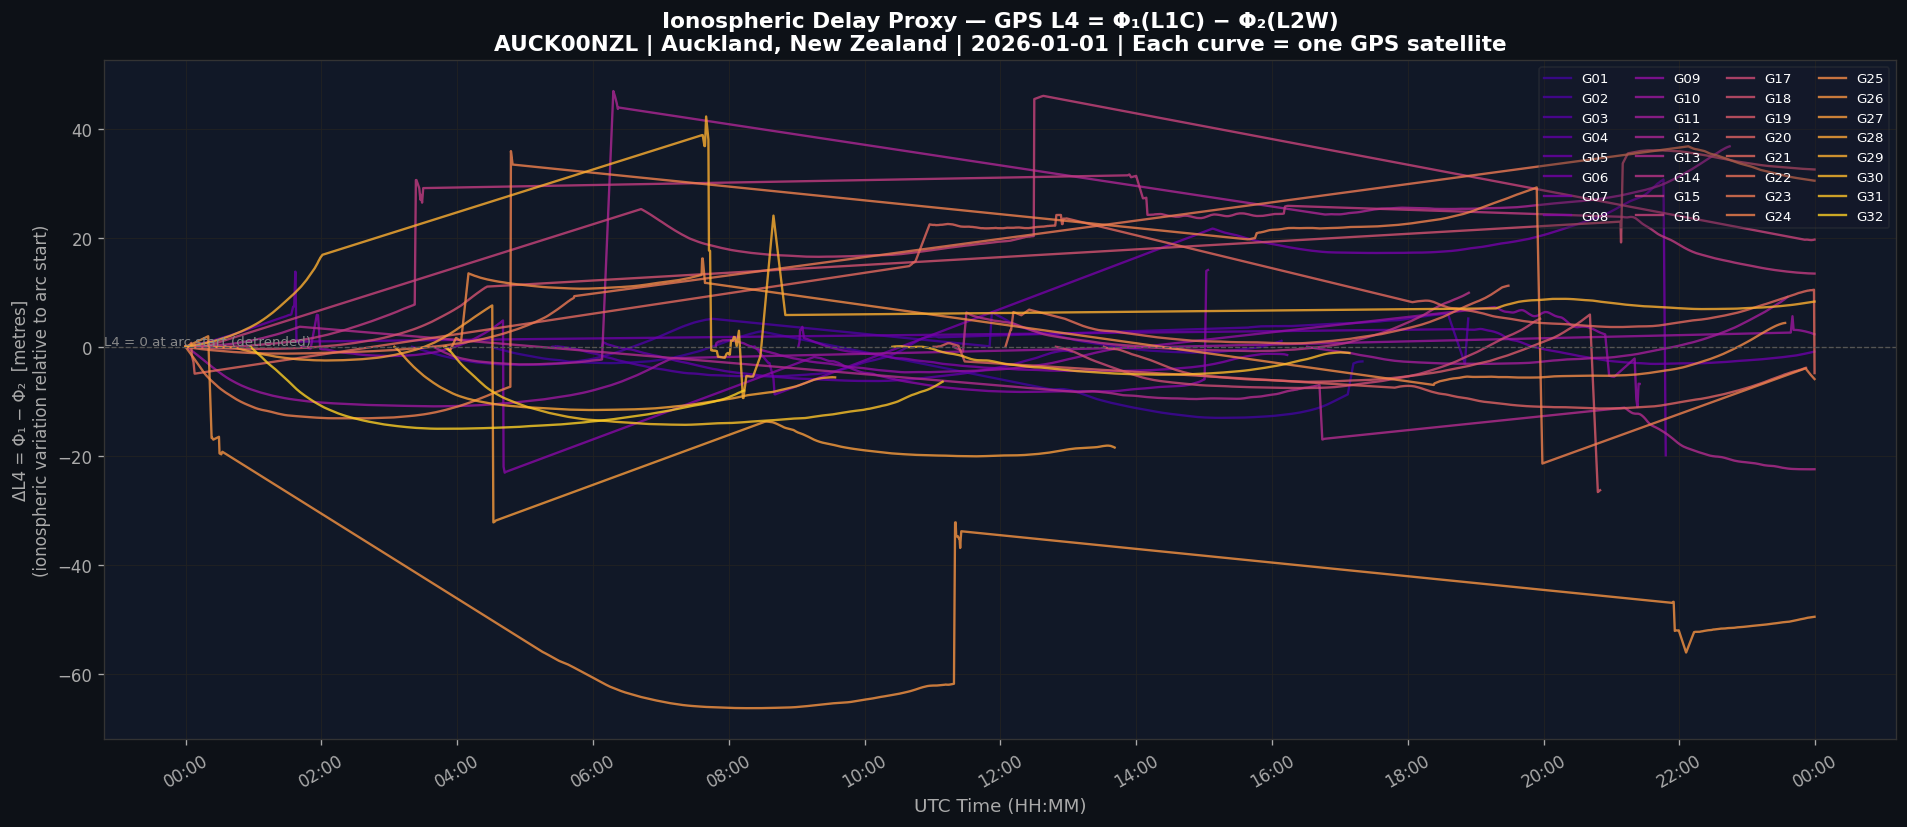

✅ Plot saved: plot1_gps_L4_timeseries.png

💡 Interpretation:
   • All curves start at 0 — the constant ambiguity term is removed
   • Smooth variation = ionospheric delay changing as satellite elevation changes
   • A sudden large jump = cycle slip (receiver lost phase lock)
   • All GPS satellites at the same station experience a similar ionospheric
     background — the shapes should be broadly similar (same ionosphere layer)


In [11]:
# ─────────────────────────────────────────────────────────
# Step 4 — Plot 1: GPS L4 Time Series (Multiple Satellites)
# ─────────────────────────────────────────────────────────
# Compute L4 for all GPS satellites

gps_sats = sorted([s for s in obs.sv.values if s.startswith('G')])
l1_gps, l2_gps, lam1_gps, lam2_gps = DUAL_FREQ['G']

gps_L4 = {}
for sat in gps_sats:
    result = compute_L4(obs, sat, l1_gps, l2_gps, lam1_gps, lam2_gps)
    if result is not None:
        gps_L4[sat] = result

print(f'GPS satellites with valid dual-frequency data: {len(gps_L4)} / {len(gps_sats)}')

# Colour palette

palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(gps_L4)))
sat_colors = {sat: palette[i] for i, sat in enumerate(gps_L4.keys())}

# Figure

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0d1117')
ax.set_facecolor('#111827')

ax.set_title(
    f'Ionospheric Delay Proxy — GPS L4 = Φ₁(L1C) − Φ₂(L2W)\n'
    'AUCK00NZL | Auckland, New Zealand | 2026-01-01 | Each curve = one GPS satellite',
    fontsize=13, fontweight='bold', color='#ffffff'
)

for sat, L4 in gps_L4.items():
    ax.plot(
        L4.index, L4.values,
        color=sat_colors[sat], lw=1.4, alpha=0.8,
        label=sat
    )

ax.axhline(0, color='#555555', lw=0.8, ls='--')

# Annotate the reference zero line
ax.text(
    ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else gps_L4[list(gps_L4.keys())[0]].index[0],
    0.3, 'L4 = 0 at arc start (detrended)',
    color='#888888', fontsize=8
)

ax.set_ylabel('ΔL4 = Φ₁ − Φ₂  [metres]\n(ionospheric variation relative to arc start)',
              color='#aaaaaa', fontsize=10)
ax.set_xlabel('UTC Time (HH:MM)', color='#aaaaaa', fontsize=11)

ax.tick_params(colors='#aaaaaa')
ax.grid(True, color='#222222', linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=30, color='#aaaaaa')

legend = ax.legend(
    ncol=4, fontsize=8, loc='upper right',
    framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444444'
)
for t in legend.get_texts():
    t.set_color('white')

plt.tight_layout()
plt.savefig('plot1_gps_L4_timeseries.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Plot saved: plot1_gps_L4_timeseries.png')
print()
print('💡 Interpretation:')
print('   • All curves start at 0 — the constant ambiguity term is removed')
print('   • Smooth variation = ionospheric delay changing as satellite elevation changes')
print('   • A sudden large jump = cycle slip (receiver lost phase lock)')
print('   • All GPS satellites at the same station experience a similar ionospheric')
print('     background — the shapes should be broadly similar (same ionosphere layer)')

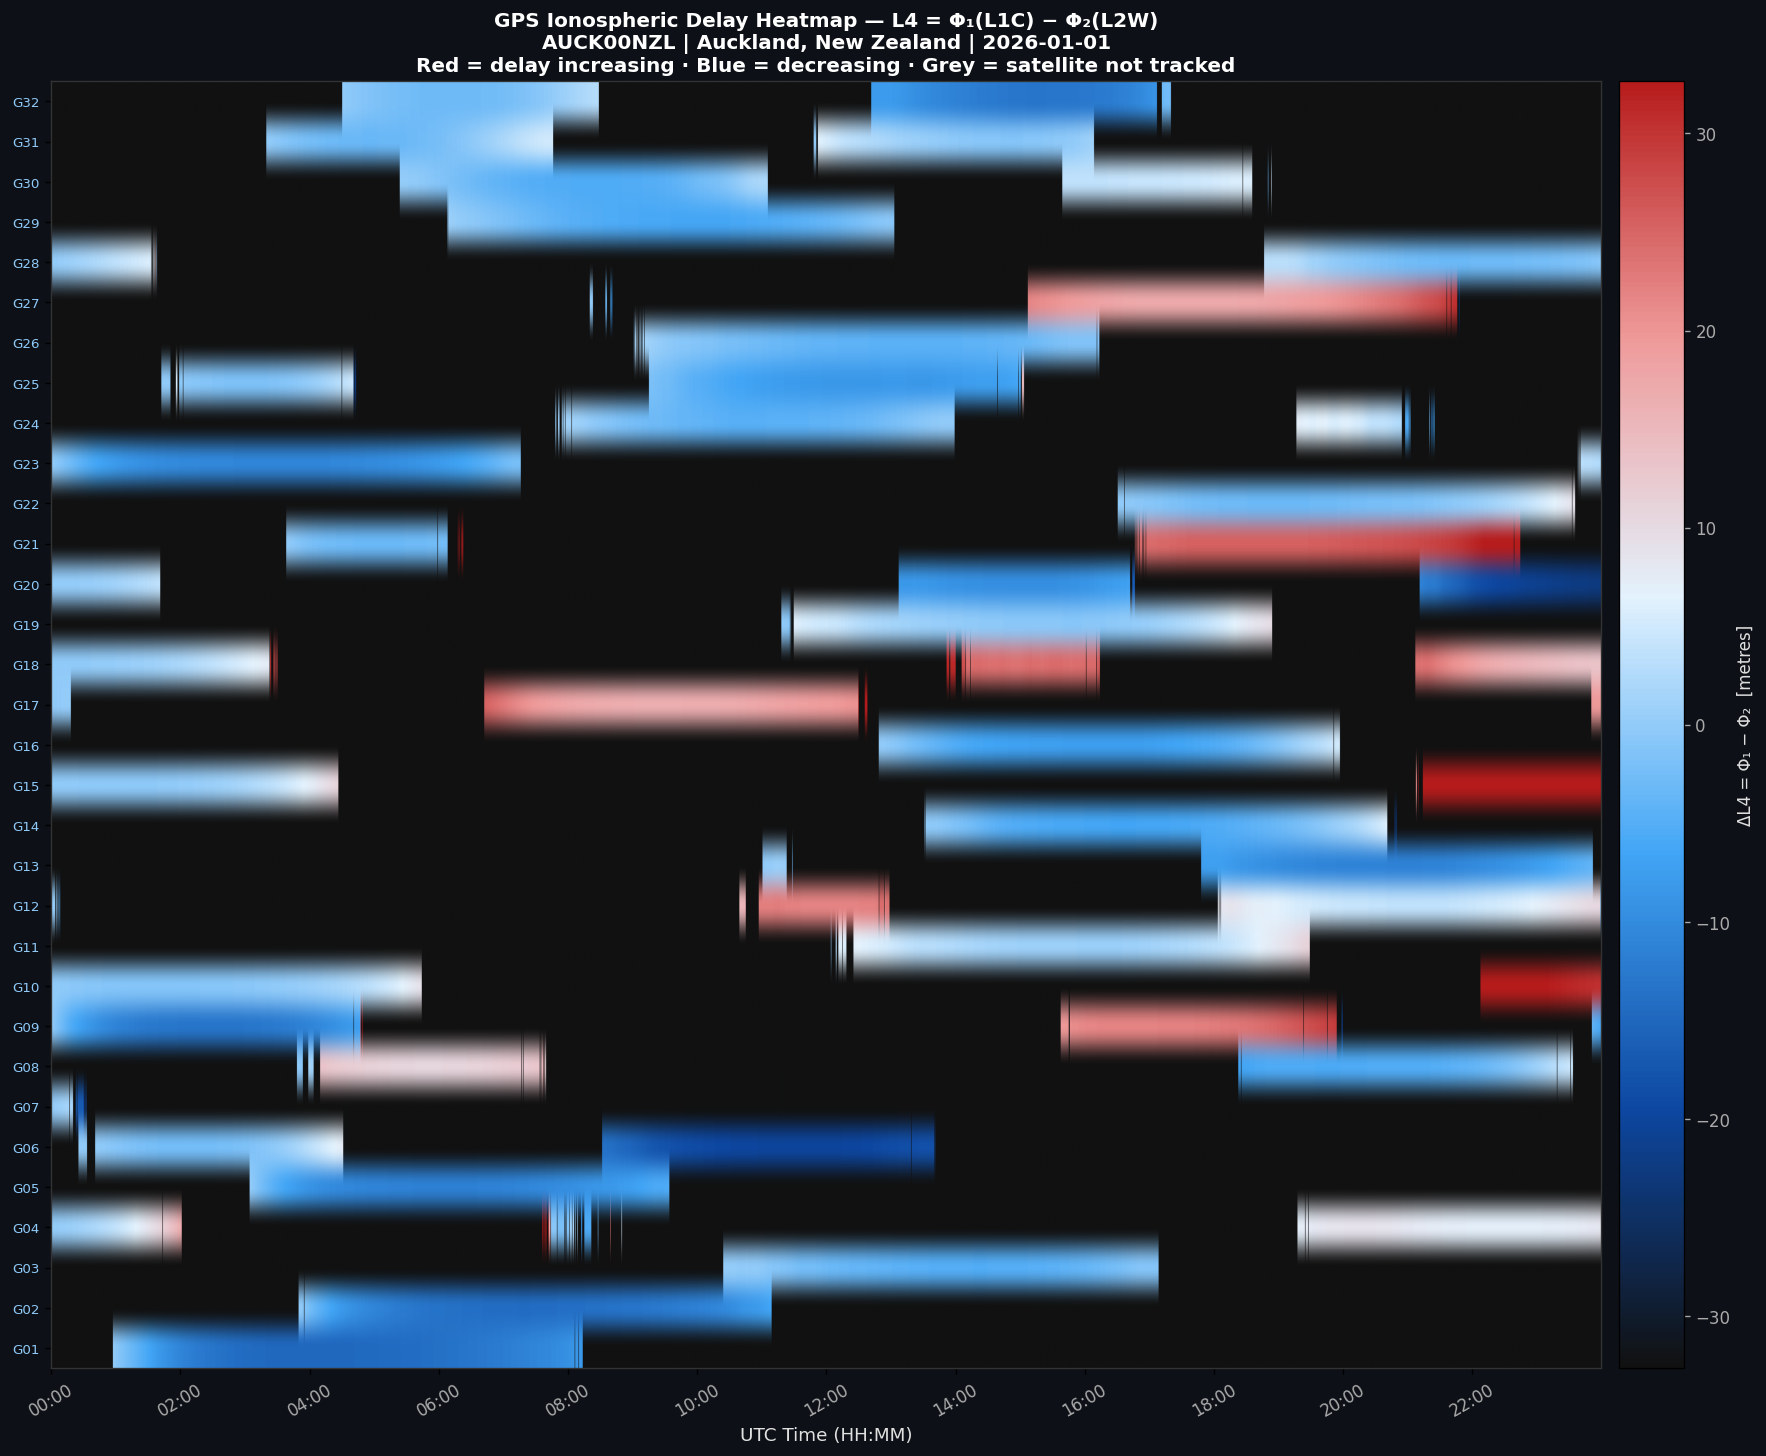

✅ Plot saved: plot2_gps_L4_heatmap.png

💡 Interpretation:
   • Dark grey = satellite below horizon (no tracking)
   • White/pale = very small ionospheric variation (quiet ionosphere)
   • Red bands = ionospheric delay increasing during that part of the arc
   • Blue bands = ionospheric delay decreasing
   • Abrupt colour jumps = cycle slips (phase discontinuities)
   • Colour scale: ±32.65 m  (95th percentile of observed L4 variation)


In [12]:
# ───────────────────────────────
# Step 5 — Plot 2: GPS L4 Heatmap
# ───────────────────────────────
# Build L4 matrix: rows = GPS satellites, columns = full time axis

time_index  = pd.to_datetime(obs.time.values)
n_epochs    = len(time_index)
ordered_sats = list(gps_L4.keys())
n_rows       = len(ordered_sats)

L4_matrix = np.full((n_rows, n_epochs), np.nan)

for i, sat in enumerate(ordered_sats):
    L4_series = gps_L4[sat]
    # Reindex to the full time axis (NaN where satellite not tracked)
    L4_matrix[i, :] = L4_series.reindex(time_index).values

# Diverging colourmap centred at 0
# Blue = negative L4 (delay decreasing)
# White = no change
# Red = positive L4 (delay increasing)

vmax = np.nanpercentile(np.abs(L4_matrix), 95)   # 95th percentile as colour limit
vmax = max(vmax, 0.5)   # minimum scale of 0.5 m for readability

# Replace NaN (not tracked) with a sentinel below vmin for display
L4_display = np.where(np.isnan(L4_matrix), -vmax * 3, L4_matrix)

# Custom diverging colormap: dark grey (no data), blue, white, red
iono_cmap = LinearSegmentedColormap.from_list(
    'iono_div',
    [
        '#111111',   # no data (below vmin)
        '#0d47a1',   # strong negative (delay decreasing)
        '#42a5f5',   # moderate negative
        '#e3f2fd',   # near zero
        '#ef9a9a',   # moderate positive
        '#b71c1c',   # strong positive (delay increasing)
    ],
    N=256
)

# Figure

fig, ax = plt.subplots(figsize=(16, max(6, n_rows * 0.32 + 2)), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

ax.imshow(
    L4_display,
    aspect='auto',
    cmap=iono_cmap,
    vmin=-vmax, vmax=vmax,
    extent=[
        mdates.date2num(time_index[0]),
        mdates.date2num(time_index[-1]),
        -0.5, n_rows - 0.5
    ],
    origin='upper'
)
ax.xaxis_date()

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=iono_cmap,
    norm=plt.Normalize(vmin=-vmax, vmax=vmax)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('ΔL4 = Φ₁ − Φ₂  [metres]', color='#e0e0e0', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
plt.setp(cbar.ax.get_yticklabels(), color='#aaaaaa')

# Satellite labels
ax.set_yticks(range(n_rows))
ax.set_yticklabels(ordered_sats, fontsize=8, color='#90CAF9')

ax.set_title(
    'GPS Ionospheric Delay Heatmap — L4 = Φ₁(L1C) − Φ₂(L2W)\n'
    'AUCK00NZL | Auckland, New Zealand | 2026-01-01\n'
    'Red = delay increasing · Blue = decreasing · Grey = satellite not tracked',
    fontsize=12, fontweight='bold', color='#ffffff'
)
ax.set_xlabel('UTC Time (HH:MM)', fontsize=11, color='#e0e0e0')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=30, color='#aaaaaa')

for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('plot2_gps_L4_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Plot saved: plot2_gps_L4_heatmap.png')
print()
print('💡 Interpretation:')
print('   • Dark grey = satellite below horizon (no tracking)')
print('   • White/pale = very small ionospheric variation (quiet ionosphere)')
print('   • Red bands = ionospheric delay increasing during that part of the arc')
print('   • Blue bands = ionospheric delay decreasing')
print('   • Abrupt colour jumps = cycle slips (phase discontinuities)')
print(f'   • Colour scale: ±{vmax:.2f} m  (95th percentile of observed L4 variation)')

  GPS       : G24  (1104 epochs)
  GLONASS   : R08  (1208 epochs)
  Galileo   : E05  (1505 epochs)
  BeiDou    : C39  (1913 epochs)
  QZSS      : J07  (2782 epochs)



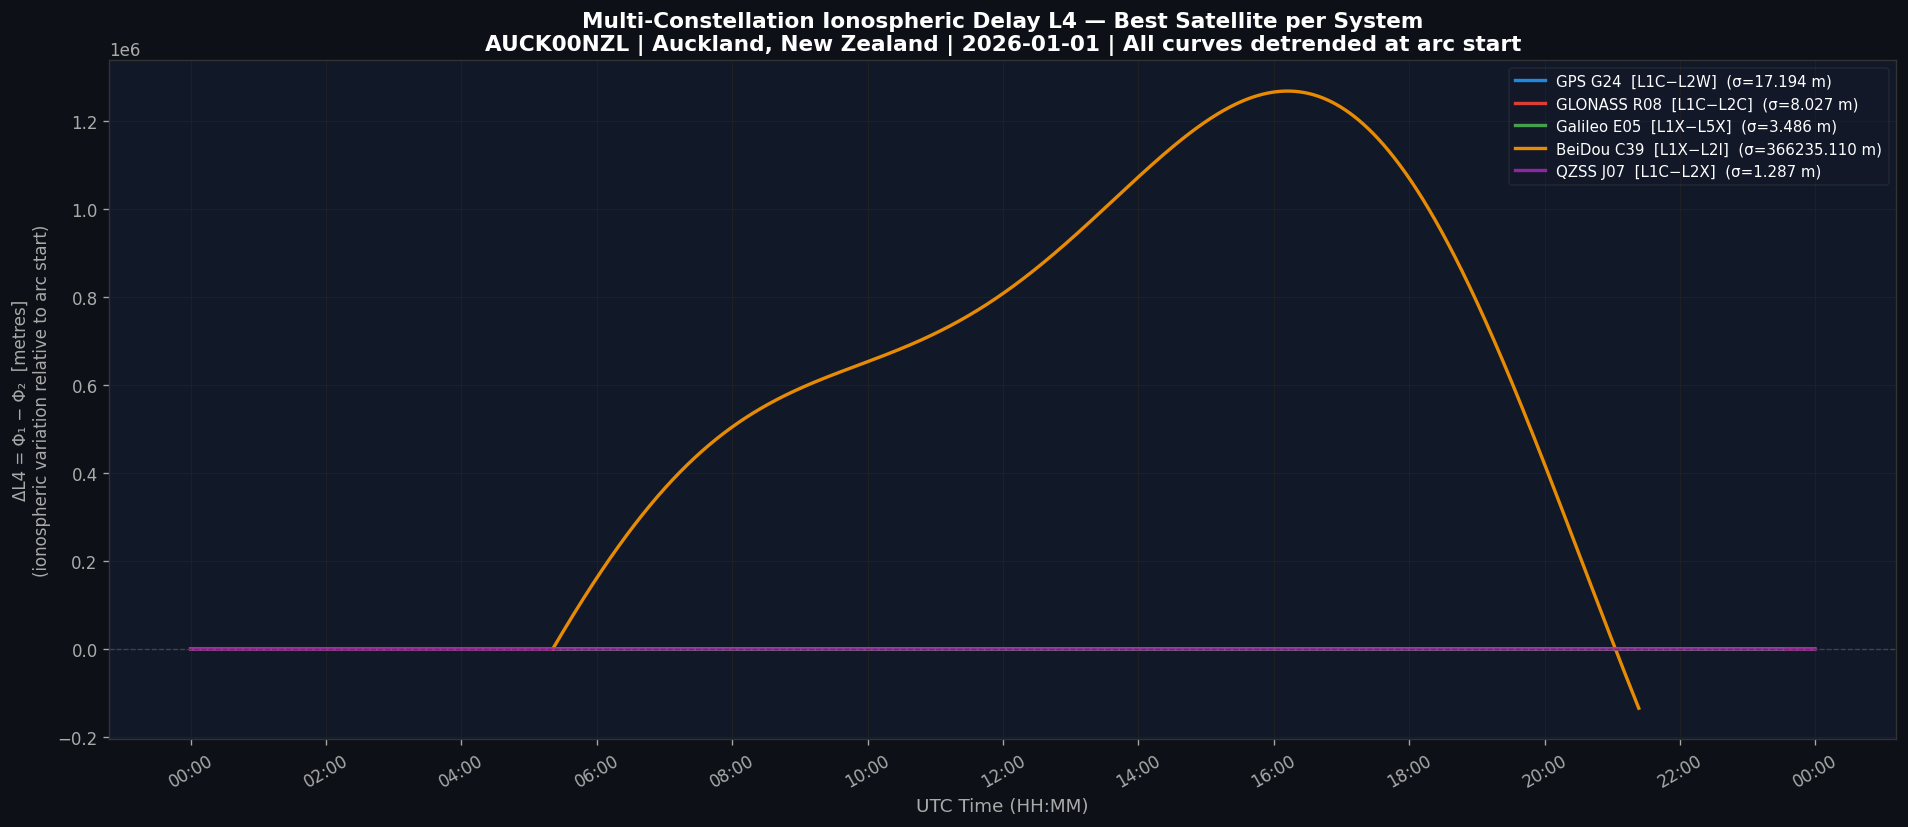

✅ Plot saved: plot3_multiconst_L4.png

💡 Interpretation:
   • Different constellations use different frequency pairs — L4 is not identical
   • But the overall ionospheric variation trend should be similar for all systems
   • because they all look through the same ionospheric layer above Auckland
   • σ (std) in legend = overall variation in L4 during the arc
   • A high σ = either a very dynamic ionosphere or cycle slips in the arc


In [13]:
# ──────────────────────────────────────────────────
# Step 6 — Plot 3: Multi-Constellation L4 Comparison
# ──────────────────────────────────────────────────
# Select best satellite per constellation

best_per_const = {}

for prefix, (l1, l2, lam1, lam2) in DUAL_FREQ.items():
    sats = sorted([s for s in obs.sv.values if s.startswith(prefix)])
    if not sats:
        continue

    best_sat = None
    best_len = 0
    best_L4  = None

    for sat in sats:
        L4 = compute_L4(obs, sat, l1, l2, lam1, lam2)
        if L4 is not None and len(L4) > best_len:
            best_len = len(L4)
            best_sat = sat
            best_L4  = L4

    if best_sat is not None:
        best_per_const[prefix] = {
            'sat':  best_sat,
            'L4':   best_L4,
            'name': CONST_NAMES[prefix],
            'color': CONST_COLORS[prefix],
            'l1':   l1, 'l2': l2,
        }
        print(f'  {CONST_NAMES[prefix]:<10}: {best_sat}  ({best_len} epochs)')

print()

# Figure

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0d1117')
ax.set_facecolor('#111827')

ax.set_title(
    'Multi-Constellation Ionospheric Delay L4 — Best Satellite per System\n'
    'AUCK00NZL | Auckland, New Zealand | 2026-01-01 | All curves detrended at arc start',
    fontsize=13, fontweight='bold', color='#ffffff'
)

for prefix, info in best_per_const.items():
    L4 = info['L4']
    ax.plot(
        L4.index, L4.values,
        color=info['color'], lw=2.0, alpha=0.9,
        label=f"{info['name']} {info['sat']}  [{info['l1']}−{info['l2']}]  "
              f"(σ={L4.std():.3f} m)"
    )

ax.axhline(0, color='#444444', lw=0.8, ls='--')

ax.set_ylabel('ΔL4 = Φ₁ − Φ₂  [metres]\n(ionospheric variation relative to arc start)',
              color='#aaaaaa', fontsize=10)
ax.set_xlabel('UTC Time (HH:MM)', color='#aaaaaa', fontsize=11)

ax.tick_params(colors='#aaaaaa')
ax.grid(True, color='#222222', linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=30, color='#aaaaaa')

legend = ax.legend(
    fontsize=9, loc='upper right',
    framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444444'
)
for t in legend.get_texts():
    t.set_color('white')

plt.tight_layout()
plt.savefig('plot3_multiconst_L4.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Plot saved: plot3_multiconst_L4.png')
print()
print('💡 Interpretation:')
print('   • Different constellations use different frequency pairs — L4 is not identical')
print('   • But the overall ionospheric variation trend should be similar for all systems')
print('   • because they all look through the same ionospheric layer above Auckland')
print('   • σ (std) in legend = overall variation in L4 during the arc')
print('   • A high σ = either a very dynamic ionosphere or cycle slips in the arc')

ROTI (GPS L1, 30-sec sampling): 0.03271 m / epoch
ROTI ≈ 0.404 TECU/min  (quiet ionosphere)


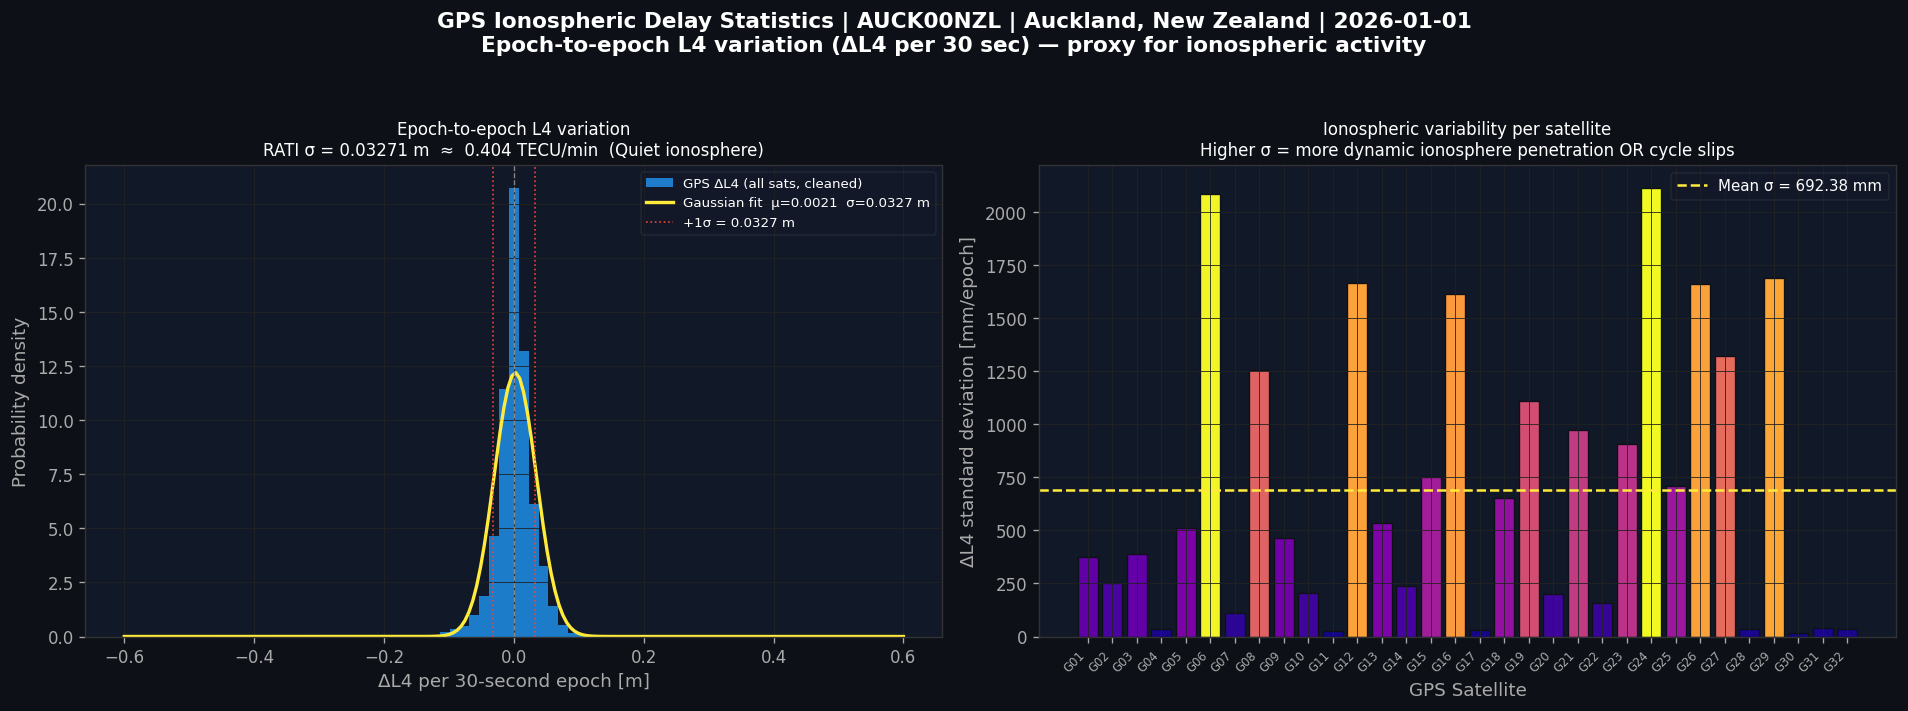

✅ Plot saved: plot4_iono_histogram.png

📊 ROTI summary:
   σ(ΔL4) = 0.03271 m  per 30-second epoch
   ≈ 0.404 TECU/min
   → Quiet ionosphere (typical for mid-latitude station)


In [14]:
# ────────────────────────────────────────────
# Step 7 — Plot 4: Ionospheric Delay Histogram
# ────────────────────────────────────────────
# ─────────────────────────────────────────────
# Compute epoch-to-epoch L4 differences for all GPS satellites
# This is the Rate of TEC Index (ROTI) precursor
# ─────────────────────────────────────────────
all_dL4 = []
for sat, L4 in gps_L4.items():
    dL4 = L4.diff().dropna()
    # Reject obvious cycle slips (> 1 m jump per 30 seconds)
    dL4_clean = dL4[np.abs(dL4) < 1.0]
    all_dL4.extend(dL4_clean.values)

all_dL4 = np.array(all_dL4)

# ROTI = std of epoch-to-epoch L4 changes [m / interval]
ROTI = all_dL4.std()

# Convert to TECU/min for reference
# 1 TECU ≈ 0.162 m on L1; interval = 30 sec = 0.5 min
ROTI_TECU = ROTI / 0.162 / 0.5   # approximate

print(f'ROTI (GPS L1, 30-sec sampling): {ROTI:.5f} m / epoch')
print(f'ROTI ≈ {ROTI_TECU:.3f} TECU/min  ({"quiet" if ROTI_TECU < 0.5 else "active"} ionosphere)')

# ─────────────────────────────────────────────
# Figure: 2 panels
# Left  = histogram of ΔL4 per epoch
# Right = cumulative L4 variation scatter for all GPS sats
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
fig.suptitle(
    'GPS Ionospheric Delay Statistics | AUCK00NZL | Auckland, New Zealand | 2026-01-01\n'
    'Epoch-to-epoch L4 variation (ΔL4 per 30 sec) — proxy for ionospheric activity',
    fontsize=13, fontweight='bold', color='#ffffff'
)

for ax in axes:
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#aaaaaa')
    ax.grid(True, color='#222222', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# ─── Left: histogram of epoch-to-epoch ΔL4 ─────────────────
bins = np.linspace(-0.6, 0.6, 80)
axes[0].hist(
    all_dL4,
    bins=bins,
    color='#2196F3', edgecolor='none', alpha=0.8,
    density=True, label=f'GPS ΔL4 (all sats, cleaned)'
)

# Fit a Gaussian for reference
from numpy import pi
mu, sigma = all_dL4.mean(), all_dL4.std()
x_fit = np.linspace(-0.6, 0.6, 200)
gaussian = (1 / (sigma * np.sqrt(2 * pi))) * np.exp(-0.5 * ((x_fit - mu) / sigma) ** 2)
axes[0].plot(x_fit, gaussian, color='#FFEB3B', lw=2.0,
             label=f'Gaussian fit  μ={mu:.4f}  σ={sigma:.4f} m')

axes[0].axvline(0, color='#888888', lw=0.8, ls='--')
axes[0].axvline(+sigma, color='#F44336', lw=1.0, ls=':', label=f'+1σ = {sigma:.4f} m')
axes[0].axvline(-sigma, color='#F44336', lw=1.0, ls=':')

axes[0].set_xlabel('ΔL4 per 30-second epoch [m]', color='#aaaaaa', fontsize=11)
axes[0].set_ylabel('Probability density', color='#aaaaaa', fontsize=11)
axes[0].set_title(
    f'Epoch-to-epoch L4 variation\nRATI σ = {ROTI:.5f} m  ≈  {ROTI_TECU:.3f} TECU/min  '
    f'({"Quiet" if ROTI_TECU < 0.5 else "Active"} ionosphere)',
    color='white', fontsize=10
)

legend0 = axes[0].legend(fontsize=8, framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444444')
for t in legend0.get_texts():
    t.set_color('white')

# ─── Right: per-satellite L4 standard deviation bar chart ──
sat_stds   = {sat: gps_L4[sat].diff().dropna().std() for sat in gps_L4}
sat_list   = list(sat_stds.keys())
std_values = [sat_stds[s] * 1000 for s in sat_list]   # convert to mm
bar_colors = plt.cm.plasma(np.array(std_values) / max(std_values))

bars = axes[1].bar(
    sat_list, std_values,
    color=bar_colors, edgecolor='#0d1117', linewidth=0.8
)

# Mean reference line
mean_std = np.mean(std_values)
axes[1].axhline(mean_std, color='#FFEB3B', ls='--', lw=1.5,
                label=f'Mean σ = {mean_std:.2f} mm')

axes[1].set_xlabel('GPS Satellite', color='#aaaaaa', fontsize=11)
axes[1].set_ylabel('ΔL4 standard deviation [mm/epoch]', color='#aaaaaa', fontsize=11)
axes[1].set_title(
    'Ionospheric variability per satellite\n'
    'Higher σ = more dynamic ionosphere penetration OR cycle slips',
    color='white', fontsize=10
)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', color='#aaaaaa', fontsize=7)

legend1 = axes[1].legend(fontsize=9, framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444444')
for t in legend1.get_texts():
    t.set_color('white')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('plot4_iono_histogram.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Plot saved: plot4_iono_histogram.png')
print()
print(f'📊 ROTI summary:')
print(f'   σ(ΔL4) = {ROTI:.5f} m  per 30-second epoch')
print(f'   ≈ {ROTI_TECU:.3f} TECU/min')
if ROTI_TECU < 0.5:
    print('   → Quiet ionosphere (typical for mid-latitude station)')
elif ROTI_TECU < 1.0:
    print('   → Mildly disturbed ionosphere')
else:
    print('   → Active ionosphere — possible scintillation')